# 05. Extended simulation -- Markov-Gaussian RSS calibration

Simulates a 2-state Markov-switching Gaussian DGP with known regime
transitions, then fits the same GMM-on-log-volatility classifier the
empirical pipeline uses, and reports the mean off-diagonal cross-frequency
ARI under both the alternative (true regimes) and a null (coarse labels
permuted). The resulting *expected* ARI under a known DGP is the
structural reference for interpreting the empirical numbers.

The notebook generates one path and walks through the analysis cell by
cell, then runs a tiny calibration grid (`n_reps=20`, single transition
rate). The cached CSV preserves the paper's full grid (`n_reps=1000`,
`P_grid=(0.005, 0.003, 0.001)`).

**Re-run command**: `python run.py extended_simulation`

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT = Path.cwd()
_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file is not None:
    PROJECT = Path(_nb_file).resolve().parent.parent
elif PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT))

OUT = PROJECT / "outputs"
OUT_2022 = PROJECT / "outputs_2022"
DATA = PROJECT / "data"
DATA_2022 = PROJECT / "data_2022"

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 50)

## Step 1 -- generate one Markov-Gaussian path

In [2]:
from src.experiments.exp_04_simulation_calibration import (
    _simulate_markov_gaussian, _aggregate_to_freq, _fit_two_state_gmm_on_logvol,
    _mean_offdiag_ari_from_labels, simulate_one_replication,
    run_simulation_calibration,
)

rng = np.random.default_rng(0)
rets, states = _simulate_markov_gaussian(n_bars_1min=5000, P=(0.02, 0.02), rng=rng)
print(f"path length     : {len(rets):,} 1-min bars")
print(f"true crisis share: {(states == 1).mean():.3f}")

path length     : 5,000 1-min bars
true crisis share: 0.524


## Step 2 -- visualise the simulated returns with state overlay

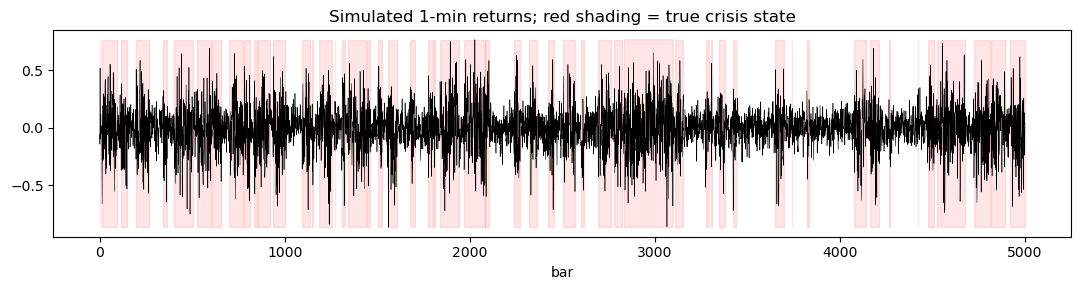

In [3]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(rets, lw=0.4, color="black")
ax.fill_between(np.arange(len(rets)), rets.min(), rets.max(),
                where=(states == 1), color="red", alpha=0.10, step="mid")
ax.set_title("Simulated 1-min returns; red shading = true crisis state")
ax.set_xlabel("bar")
plt.tight_layout()
plt.show()

## Step 3 -- aggregate to 5m / 15m / 1h, fit GMM on log-vol per frequency

In [4]:
labels_by_freq = {}
for name, block in (("5m", 5), ("15m", 15), ("1h", 60)):
    _, vol = _aggregate_to_freq(rets, block)
    labels_by_freq[name] = _fit_two_state_gmm_on_logvol(vol)
    print(f"{name}: n_bars={len(vol):>5d} crisis_share={labels_by_freq[name].mean():.3f}")
print(f"mean off-diag ARI (intraday, single rep): "
      f"{_mean_offdiag_ari_from_labels(labels_by_freq):.4f}")

5m: n_bars= 1000 crisis_share=0.502


15m: n_bars=  333 crisis_share=0.580
1h: n_bars=   83 crisis_share=0.627
mean off-diag ARI (intraday, single rep): 0.3703


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

## Step 4 -- small calibration grid (n_reps=20, single transition rate)

Reduced workload (~20 s) that demonstrates the structure of the cached
table; the paper number uses `n_reps=1000` and three transition rates.

In [5]:
from tempfile import TemporaryDirectory
with TemporaryDirectory() as td:
    out = run_simulation_calibration(
        Path(td), n_reps=20, n_bars_1min=5000, P_grid=(0.02,), seed=42,
    )
pd.DataFrame([out])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

...

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,P_trans,n_reps_used,alt_mean_all4,alt_q25_all4,alt_q75_all4,alt_mean_intraday,alt_q25_intraday,alt_q75_intraday,alt_frac_below_0p20_all4,null_mean_all4,null_q975_all4,null_mean_intraday,null_q975_intraday
0,0.02,20,0.344,0.296,0.378,0.344,0.296,0.378,0.0,0.001,0.011,0.001,0.011


## Cached full-scale calibration -- `outputs/simulation_rss.csv`

In [6]:
p = OUT / "simulation_rss.csv"
display(pd.read_csv(p).round(3) if p.exists() else Markdown(f"`{p}` missing"))

,P_trans,n_reps_used,alt_mean_all4,alt_q25_all4,alt_q75_all4,alt_mean_intraday,alt_q25_intraday,alt_q75_intraday,alt_frac_below_0p20_all4,null_mean_all4,null_q975_all4,null_mean_intraday,null_q975_intraday
0,0.005,1000,0.298,0.285,0.309,0.577,0.557,0.596,0.0,0.001,0.007,0.001,0.004
1,0.003,1000,0.337,0.321,0.350,0.639,0.622,0.655,0.0,0.002,0.010,0.001,0.004
2,0.001,1000,0.411,0.373,0.441,0.713,0.696,0.728,0.0,0.003,0.018,0.001,0.006


## Cached detection-rate calibration -- `outputs/simulation_detection_rate.csv`

In [7]:
p = OUT / "simulation_detection_rate.csv"
display(pd.read_csv(p).round(3) if p.exists() else Markdown(f"`{p}` missing"))

,delta_bar,detection_rate
0,0.05,0.0
1,0.10,0.0
2,0.15,0.0
3,0.20,0.0
